# Dataset to train the predicting model

c:\Users\laiar\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


k=2: silhouette=0.5395
k=3: silhouette=0.5299
k=4: silhouette=0.5505
k=5: silhouette=0.5078
k=6: silhouette=0.5144
k=7: silhouette=0.4940
k=8: silhouette=0.4721
k=9: silhouette=0.4747
k=10: silhouette=0.4793

Best k: 4


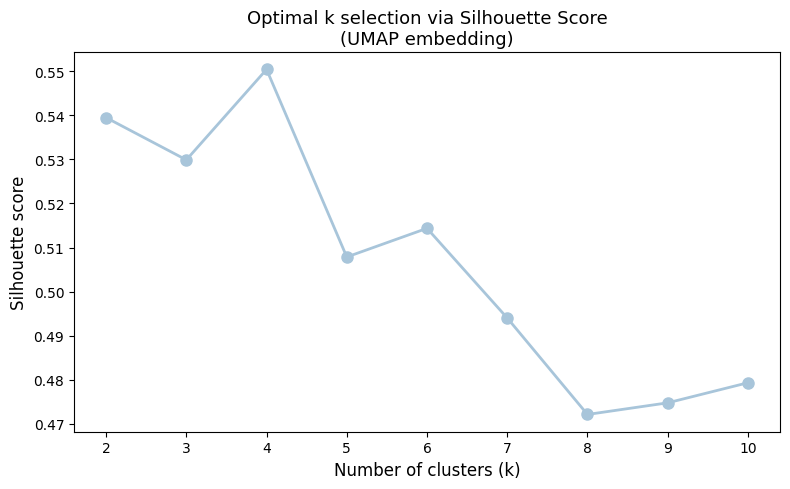

In [10]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np
import umap
import matplotlib.pyplot as plt

pdc_cols = [c for c in pdc_switchers_csv.columns if c.startswith('Month_')]
X = pdc_switchers_csv[pdc_cols].values

reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

silhouette_scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embedding)
    score = silhouette_score(embedding, labels)
    silhouette_scores[k] = score
    print(f"k={k}: silhouette={score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k: {best_k}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), 
         marker='o', color='#A8C5DA', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Silhouette score', fontsize=12)
plt.title('Optimal k selection via Silhouette Score\n(UMAP embedding)', fontsize=13)
plt.xticks(range(2, 11))
plt.tight_layout()

plt.show()

In [62]:
import pandas as pd
import numpy as np

# 1. Load existing files 
pdc = pd.read_csv(r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\pdc_monthly_wide_clusters.csv')        # has idCas, Month_-12..-1, cluster
socio = pd.read_csv(r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\cohort_schizophrenia_sociodemografica.csv')  # idCas, SEXE1, EDAT_rang, NIVSOC

# Visit tables (adjust column names to yours)
urg = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\Datos_padris_schizo\urg_epi_dx_proc_schizophrenia.csv")    # idCas, dat_ini
smh = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\Datos_padris_schizo\smh_epi_dx_proc_schizophrenia.csv")           # idCas, dat_ini
sma = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\Datos_padris_schizo\sma_cap_dx_schizophrenia.csv")           # idCas, dat_ini (or Data inici assistencia)

# Dispensing + LAI info (you need first_lai_date and switch year from here)
annual = pd.read_csv(r"C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\pdc_per_patient_year.csv")  # idCas, first_lai_date, is_switch_year

print(sma.columns.tolist())

['idCas', 'id_cmbd', 'Data inici assistència', 'Procedència ingrés', 'Pro_ingres_Codi', 'Data fi assistència', 'Visites en centres ambulatoris de salut mental', 'pos_diag_1', 'diag_1', 'pos_diag_2', 'diag_2', 'pos_diag_3', 'diag_3', 'pos_diag_4', 'diag_4']


In [63]:
sma.columns = [c.strip() for c in sma.columns]
sma = sma.rename(columns={sma.columns[2]: 'dat_ini'})
sma['dat_ini'] = pd.to_datetime(sma['dat_ini'], format='%Y%m%d')
sma_counts = count_preswitch_visits(sma, 'dat_ini', switch_dates, 'sma')

In [33]:
print(sma.columns.tolist())

['idCas', 'id_cmbd', 'dat_ini', 'Procedència ingrés', 'Pro_ingres_Codi', 'Data fi assistència', 'Visites en centres ambulatoris de salut mental', 'pos_diag_1', 'diag_1', 'pos_diag_2', 'diag_2', 'pos_diag_3', 'diag_3', 'pos_diag_4', 'diag_4']


In [23]:
print(t25.columns.tolist())

['id', 'idCas', 'Any_Mes', '(HIS) Subgrup 7 (ATC)', '(HIS) Subgrup 7 (ATC) Desc', '(HIS) Forma Farmacèutica', '(HIS) Forma Farmacèutica Desc', '(HIS) Producte', '(HIS) Producte Desc', '(HIS) Via de distribució', 'Concepte Facturació', 'Concepte Facturació Desc', 'Import activitat MHDA']


In [64]:
first_lai = t25.sort_values('Any_Mes').groupby('idCas').first().reset_index()[['idCas', '(HIS) Producte Desc']]
first_lai.columns = ['idCas', 'first_lai_product']

In [36]:
pdc['cluster_k4'].value_counts()

cluster_k4
0    321
1    319
3    198
2    187
Name: count, dtype: int64

In [70]:
# 3. Pre-switch PDC features 
pre_cols = [f'Month_{i}' for i in range(-12, 0)]
features = pdc[['idCas', 'cluster_k4'] + pre_cols].copy()

# 4. Switch date and year 
# Get one row per switcher with their first_lai_date
switch_info = (
    annual[annual['switcher'] == True][['idCas', 'first_lai_date']]
    .drop_duplicates('idCas')
)
switch_info['first_lai_date'] = pd.to_datetime(switch_info['first_lai_date'])
switch_info['switch_year'] = switch_info['first_lai_date'].dt.year

features = features.merge(switch_info[['idCas', 'first_lai_date', 'switch_year']], on='idCas', how='left')

# 5. Pre-switch psychiatric visit counts 
def count_preswitch_visits(visit_df, date_col, switch_dates, label):
    visit_df = visit_df.copy()
    visit_df[date_col] = pd.to_datetime(visit_df[date_col])
    merged = visit_df.merge(switch_dates, on='idCas', how='inner')
    pre = merged[
        (merged[date_col] >= merged['first_lai_date'] - pd.DateOffset(months=12)) &
        (merged[date_col] < merged['first_lai_date'])
    ]
    counts = pre.groupby('idCas').size().reset_index(name=f'n_{label}_pre')
    return counts

switch_dates = features[['idCas', 'first_lai_date']]

urg_counts = count_preswitch_visits(urg, 'dat_ini', switch_dates, 'urg')
smh_counts = count_preswitch_visits(smh, 'dat_ini', switch_dates, 'smh')
sma_counts = count_preswitch_visits(sma, 'dat_ini', switch_dates, 'sma')

for counts in [urg_counts, smh_counts, sma_counts]:
    features = features.merge(counts, on='idCas', how='left')

# Fill 0 for patients with no visits
features[['n_urg_pre', 'n_smh_pre', 'n_sma_pre']] = features[['n_urg_pre', 'n_smh_pre', 'n_sma_pre']].fillna(0)

# 6. Sociodemographics
features = features.merge(socio[['idCas', 'SEXE1', 'EDAT_rang', 'NIVSOC']], on='idCas', how='left')

# 7. Which LAI they switched to
# Load dispensing table and find first LAI dispensing per patient
# Adjust table/column names to yours
t25 = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\25_taula_farmacs_mhda_2010_2019_Final.csv")  # hospital dispensing (LAIs)

# Get first LAI product per patient
t25['Any_Mes'] = pd.to_datetime(t25['Any_Mes'], format='%Y%m')
first_lai = t25.sort_values('Any_Mes').groupby('idCas').first().reset_index()[['idCas', '(HIS) Producte Desc']]
first_lai.columns = ['idCas', 'first_lai_product']

# Simplify to drug name (adjust keywords to match your product names)
def classify_lai(name):
    name = str(name).upper()
    if 'XEPLION' in name or 'TREVICTA' in name:
        return 'paliperidone'
    elif 'ABILIFY MAINTENA' in name:
        return 'aripiprazole'
    elif 'RISPERDAL CONSTA' in name:
        return 'risperidone'
    elif 'ZYPADHERA' in name:
        return 'olanzapine'
    elif 'HALDOL' in name and ('DECANOATE' in name or 'DEPOT' in name):
        return 'haloperidol'
    else:
        return 'other'

first_lai['lai_type'] = first_lai['first_lai_product'].apply(classify_lai)
features = features.merge(first_lai[['idCas', 'lai_type']], on='idCas', how='left')

# 8. Oral antipsychotic type pre-switch
# From community pharmacy table (Table 23)
t23 = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\23_antipsicotics_dispensats.csv")
t23['Any_Mes'] = pd.to_datetime(t23['Any_Mes'], format='%Y%m')

# Keep only pre-switch dispensings
t23 = t23.merge(switch_dates, on='idCas', how='inner')
t23_pre = t23[t23['Any_Mes'] < t23['first_lai_date']]

# Most frequent oral drug per patient
most_common_oral = (
    t23_pre.groupby(['idCas', 'DES_HIS_Producte'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates('idCas')[['idCas', 'DES_HIS_Producte']]
)
most_common_oral.columns = ['idCas', 'main_oral_product']

def classify_oral(name):
    name = str(name).upper()
    if 'RISPERIDONA' in name or 'RISPERDAL' in name:
        return 'risperidone'
    elif 'OLANZAPINA' in name or 'ZYPREXA' in name:
        return 'olanzapine'
    elif 'QUETIAPINA' in name or 'SEROQUEL' in name:
        return 'quetiapine'
    elif 'ARIPIPRAZOL' in name or 'ABILIFY' in name:
        return 'aripiprazole'
    elif 'PALIPERIDONA' in name or 'INVEGA' in name:
        return 'paliperidone'
    elif 'CLOZAPINA' in name or 'LEPONEX' in name:
        return 'clozapine'
    elif 'HALOPERIDOL' in name:
        return 'haloperidol'
    elif 'AMISULPIRIDA' in name:
        return 'amisulpride'
    elif 'QUETIAPINA' in name:
        return 'quetiapine'
    elif 'SULPIRIDA' in name:
        return 'sulpiride'
    elif 'LURASIDONA' in name:
        return 'lurasidone'
    else:
        return 'other'

most_common_oral['oral_type'] = most_common_oral['main_oral_product'].apply(classify_oral)
features = features.merge(most_common_oral[['idCas', 'oral_type']], on='idCas', how='left')

# 9. Encode categoricals
features = pd.get_dummies(features, columns=['SEXE1', 'EDAT_rang', 'NIVSOC', 'lai_type', 'oral_type', 'switch_year'])

# 10. Final feature matrix
drop_cols = ['idCas', 'first_lai_date', 'cluster_k4']
X = features.drop(columns=drop_cols)
y = features['cluster_k4']

print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution:\n{y.value_counts()}")
print(f"Missing values:\n{X.isnull().sum()[X.isnull().sum() > 0]}")

C:\Users\laiar\AppData\Local\Temp\ipykernel_31988\996706657.py:74: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  t23 = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\23_antipsicotics_dispensats.csv")


Feature matrix shape: (1025, 49)
Label distribution:
cluster_k4
0    321
1    319
3    198
2    187
Name: count, dtype: int64
Missing values:
Series([], dtype: int64)


In [71]:
# Carrega el fitxer complet sense filtrar per antipsicòtics
t23_full = pd.read_csv(r'C:\Users\laiar\Desktop\DATOS_PADRIS_nets\23_antipsicotics_dispensats.csv', low_memory=False)
t23_full['Any_Mes'] = pd.to_datetime(t23_full['Any_Mes'], format='%Y%m')

# Merge amb switch dates
t23_full = t23_full.merge(switch_dates, on='idCas', how='inner')

# Filtra pre-switch
t23_full_pre = t23_full[t23_full['Any_Mes'] < t23_full['first_lai_date']]

# Compta ATC únics per pacient en els 12 mesos pre-switch
polypharmacy = (
    t23_full_pre
    .groupby('idCas')['ID_HIS_Subgrup_7_ATC']
    .nunique()
    .reset_index(name='n_unique_atc_pre')
)

print(polypharmacy['n_unique_atc_pre'].describe())
print(f"\nPatients with ≥5 ATC codes: {(polypharmacy['n_unique_atc_pre'] >= 5).sum()}")

count    1025.000000
mean        2.802927
std         1.149130
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         6.000000
Name: n_unique_atc_pre, dtype: float64

Patients with ≥5 ATC codes: 87


In [72]:
# Merge into features
features = features.merge(polypharmacy, on='idCas', how='left')
features['n_unique_atc_pre'] = features['n_unique_atc_pre'].fillna(0)

In [116]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Load existing files 
pdc = pd.read_csv(r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\pdc_monthly_wide_clusters.csv')        # has idCas, Month_-12..-1, cluster
socio = pd.read_csv(r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\cohort_schizophrenia_sociodemografica.csv')  # idCas, SEXE1, EDAT_rang, NIVSOC
# Visit tables (adjust column names to yours)
urg = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\Datos_padris_schizo\urg_epi_dx_proc_schizophrenia.csv")    # idCas, dat_ini
smh = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\Datos_padris_schizo\smh_epi_dx_proc_schizophrenia.csv")           # idCas, dat_ini
sma = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\Datos_padris_schizo\sma_cap_dx_schizophrenia.csv")           # idCas, dat_ini (or Data inici assistencia)
# Dispensing + LAI info (you need first_lai_date and switch year from here)
annual = pd.read_csv(r"C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\pdc_per_patient_year.csv")  # idCas, first_lai_date, is_switch_year
t25    = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\25_taula_farmacs_mhda_2010_2019_Final.csv")
t23    = pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\23_antipsicotics_dispensats.csv", low_memory=False)

# ── 2. Pre-switch PDC features + target ──────────────────────────────────────
pre_cols = [f'Month_{i}' for i in range(-12, 0)]
features = pdc[['idCas', 'cluster_k4'] + pre_cols].copy()

# ── 3. Switch date and year ───────────────────────────────────────────────────
switch_info = (
    annual[annual['switcher'] == True][['idCas', 'first_lai_date']]
    .drop_duplicates('idCas')
)
switch_info['first_lai_date'] = pd.to_datetime(switch_info['first_lai_date'])
switch_info['switch_year'] = switch_info['first_lai_date'].dt.year
features = features.merge(switch_info[['idCas', 'first_lai_date', 'switch_year']], on='idCas', how='left')

# ── 4. Pre-switch psychiatric visit counts ────────────────────────────────────
switch_dates = features[['idCas', 'first_lai_date']]

def count_preswitch_visits(visit_df, date_col, switch_dates, label):
    visit_df = visit_df.copy()
    visit_df[date_col] = pd.to_datetime(visit_df[date_col])
    merged = visit_df.merge(switch_dates, on='idCas', how='inner')
    pre = merged[
        (merged[date_col] >= merged['first_lai_date'] - pd.DateOffset(months=12)) &
        (merged[date_col] <  merged['first_lai_date'])
    ]
    return pre.groupby('idCas').size().reset_index(name=f'n_{label}_pre')

sma = sma.rename(columns={sma.columns[2]: 'dat_ini'})
sma['dat_ini'] = pd.to_datetime(sma['dat_ini'], format='%Y%m%d')

urg_counts = count_preswitch_visits(urg, 'dat_ini', switch_dates, 'urg')
smh_counts = count_preswitch_visits(smh, 'dat_ini', switch_dates, 'smh')
sma_counts = count_preswitch_visits(sma, 'dat_ini', switch_dates, 'sma')

for counts in [urg_counts, smh_counts, sma_counts]:
    features = features.merge(counts, on='idCas', how='left')
features[['n_urg_pre', 'n_smh_pre', 'n_sma_pre']] = features[['n_urg_pre', 'n_smh_pre', 'n_sma_pre']].fillna(0)

# ── 5. Sociodemographics ──────────────────────────────────────────────────────
features = features.merge(socio[['idCas', 'SEXE1', 'EDAT_rang', 'NIVSOC']], on='idCas', how='left')

# ── 6. LAI type ───────────────────────────────────────────────────────────────
t25['Any_Mes'] = pd.to_datetime(t25['Any_Mes'], format='%Y%m')
first_lai = (
    t25.sort_values('Any_Mes')
    .groupby('idCas').first()
    .reset_index()[['idCas', '(HIS) Producte Desc']]
)
first_lai.columns = ['idCas', 'first_lai_product']

def classify_lai(name):
    name = str(name).upper()
    if 'XEPLION' in name or 'TREVICTA' in name:   return 'paliperidone'
    elif 'ABILIFY MAINTENA' in name:                return 'aripiprazole'
    elif 'RISPERDAL CONSTA' in name:                return 'risperidone'
    elif 'ZYPADHERA' in name:                       return 'olanzapine'
    elif 'HALDOL' in name and ('DECANOATE' in name or 'DEPOT' in name): return 'haloperidol'
    else:                                            return 'other'

first_lai['lai_type'] = first_lai['first_lai_product'].apply(classify_lai)
features = features.merge(first_lai[['idCas', 'lai_type']], on='idCas', how='left')

# ── 7. Oral type pre-switch ───────────────────────────────────────────────────
t23['Any_Mes'] = pd.to_datetime(t23['Any_Mes'], format='%Y%m')
t23 = t23.merge(switch_dates, on='idCas', how='inner')
t23_pre = t23[t23['Any_Mes'] < t23['first_lai_date']]

most_common_oral = (
    t23_pre.groupby(['idCas', 'DES_HIS_Producte'])
    .size().reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates('idCas')[['idCas', 'DES_HIS_Producte']]
)
most_common_oral.columns = ['idCas', 'main_oral_product']

def classify_oral(name):
    name = str(name).upper()
    if   'RISPERIDONA' in name or 'RISPERDAL' in name: return 'risperidone'
    elif 'OLANZAPINA'  in name or 'ZYPREXA'   in name: return 'olanzapine'
    elif 'QUETIAPINA'  in name or 'SEROQUEL'  in name: return 'quetiapine'
    elif 'ARIPIPRAZOL' in name or 'ABILIFY'   in name: return 'aripiprazole'
    elif 'PALIPERIDONA' in name or 'INVEGA'   in name: return 'paliperidone'
    elif 'CLOZAPINA'   in name or 'LEPONEX'   in name: return 'clozapine'
    elif 'HALOPERIDOL' in name:                         return 'haloperidol'
    elif 'AMISULPIRIDA' in name:                        return 'amisulpride'
    elif 'SULPIRIDA'   in name:                         return 'sulpiride'
    elif 'LURASIDONA'  in name:                         return 'lurasidone'
    else:                                               return 'other'

most_common_oral['oral_type'] = most_common_oral['main_oral_product'].apply(classify_oral)
features = features.merge(most_common_oral[['idCas', 'oral_type']], on='idCas', how='left')

# Polypharmacy merge BEFORE get_dummies
features = features.merge(polypharmacy, on='idCas', how='left')
features['n_unique_atc_pre'] = features['n_unique_atc_pre'].fillna(0)

# ── 8. Encode categoricals ────────────────────────────────────────────────────
features = pd.get_dummies(features, columns=['SEXE1', 'EDAT_rang', 'NIVSOC', 'lai_type', 'oral_type', 'switch_year'])

# ── 9. Final arrays ───────────────────────────────────────────────────────────
drop_cols = ['idCas', 'first_lai_date', 'cluster_k4']
X = features.drop(columns=drop_cols)
y = features['cluster_k4']

print(f"Feature matrix: {X.shape}")
print(f"Label distribution:\n{y.value_counts()}")
print(f"Missing values: {X.isnull().sum().sum()}")

X_arr = X.values
y_arr = y.values
n_classes = len(np.unique(y_arr))

# ── 10. Train/test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr, test_size=0.20, random_state=42, stratify=y_arr
)

# ── 11. Evaluation helper ─────────────────────────────────────────────────────
def evaluate(pipeline, X_test, y_test, n_classes):
    preds = pipeline.predict(X_test)
    probs = pipeline.predict_proba(X_test)
    y_bin = label_binarize(y_test, classes=range(n_classes))
    return {
        'AUC':       roc_auc_score(y_bin, probs, average='macro', multi_class='ovr'),
        'Recall':    recall_score(y_test, preds, average='macro', zero_division=0),
        'Precision': precision_score(y_test, preds, average='macro', zero_division=0),
        'Accuracy':  accuracy_score(y_test, preds)
    }

# ── 12. Optuna objectives ─────────────────────────────────────────────────────
def make_objective(model_class, extra_params={}):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth':    trial.suggest_int('max_depth', 3, 12),
            **extra_params
        }
        if model_class in [XGBClassifier, LGBMClassifier]:
            params['learning_rate'] = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train[tr_idx], X_train[val_idx]
            y_tr, y_val = y_train[tr_idx], y_train[val_idx]
            pipe = Pipeline([('scaler', StandardScaler()), ('model', model_class(**params))])
            pipe.fit(X_tr, y_tr)
            y_val_bin = label_binarize(y_val, classes=range(n_classes))
            probs = pipe.predict_proba(X_val)
            scores.append(roc_auc_score(y_val_bin, probs, average='macro', multi_class='ovr'))
        return np.mean(scores)
    return objective

# ── 13. Run tuning and evaluation ─────────────────────────────────────────────
studies_config = {
    'Random Forest': (RandomForestClassifier, {'random_state': 42, 'class_weight': 'balanced', 'n_jobs': -1}),
    'XGBoost':       (XGBClassifier,          {'random_state': 42, 'eval_metric': 'mlogloss', 'n_jobs': -1}),
    'LightGBM':      (LGBMClassifier,         {'random_state': 42, 'class_weight': 'balanced', 'verbosity': -1, 'n_jobs': -1}),
}

results = {}
best_overall_auc = -1
final_pipe = None
best_model_name = ""

print("\nStarting Optuna tuning (5-fold CV, 20 trials each)...")

for name, (model_class, extra_params) in studies_config.items():
    print(f"\n--- Tuning {name} ---")
    study = optuna.create_study(direction='maximize')
    study.optimize(make_objective(model_class, extra_params), n_trials=20)

    print(f"Best CV AUC: {study.best_value:.4f}")
    print(f"Best params: {study.best_params}")

    best_params = {**study.best_params, **extra_params}
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model_class(**best_params))])
    pipe.fit(X_train, y_train)

    metrics = evaluate(pipe, X_test, y_test, n_classes)
    results[name] = metrics

    if metrics['AUC'] > best_overall_auc:
        best_overall_auc = metrics['AUC']
        final_pipe = pipe
        best_model_name = name

# ── 14. Results ───────────────────────────────────────────────────────────────
print("\n================ TEST SET PERFORMANCE ================")
metrics_df = pd.DataFrame(results).T
print(metrics_df.to_string(formatters={k: '{:.2%}'.format for k in ['AUC', 'Recall', 'Precision', 'Accuracy']}))
print(f"\n🏆 Best model: {best_model_name} (AUC: {best_overall_auc:.2%})")

Feature matrix: (1025, 50)
Label distribution:
cluster_k4
0    321
1    319
3    198
2    187
Name: count, dtype: int64
Missing values: 0

Starting Optuna tuning (5-fold CV, 20 trials each)...

--- Tuning Random Forest ---
Best CV AUC: 0.9038
Best params: {'n_estimators': 237, 'max_depth': 9}

--- Tuning XGBoost ---
Best CV AUC: 0.8976
Best params: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1102070653681312}

--- Tuning LightGBM ---
Best CV AUC: 0.8948
Best params: {'n_estimators': 275, 'max_depth': 6, 'learning_rate': 0.09027471715082694}

================ TEST SET PERFORMANCE ================
                 AUC Recall Precision Accuracy
Random Forest 88.77% 69.50%    65.86%   75.12%
XGBoost       88.86% 67.73%    59.82%   74.63%
LightGBM      86.82% 62.42%    60.06%   67.80%

🏆 Best model: XGBoost (AUC: 88.86%)


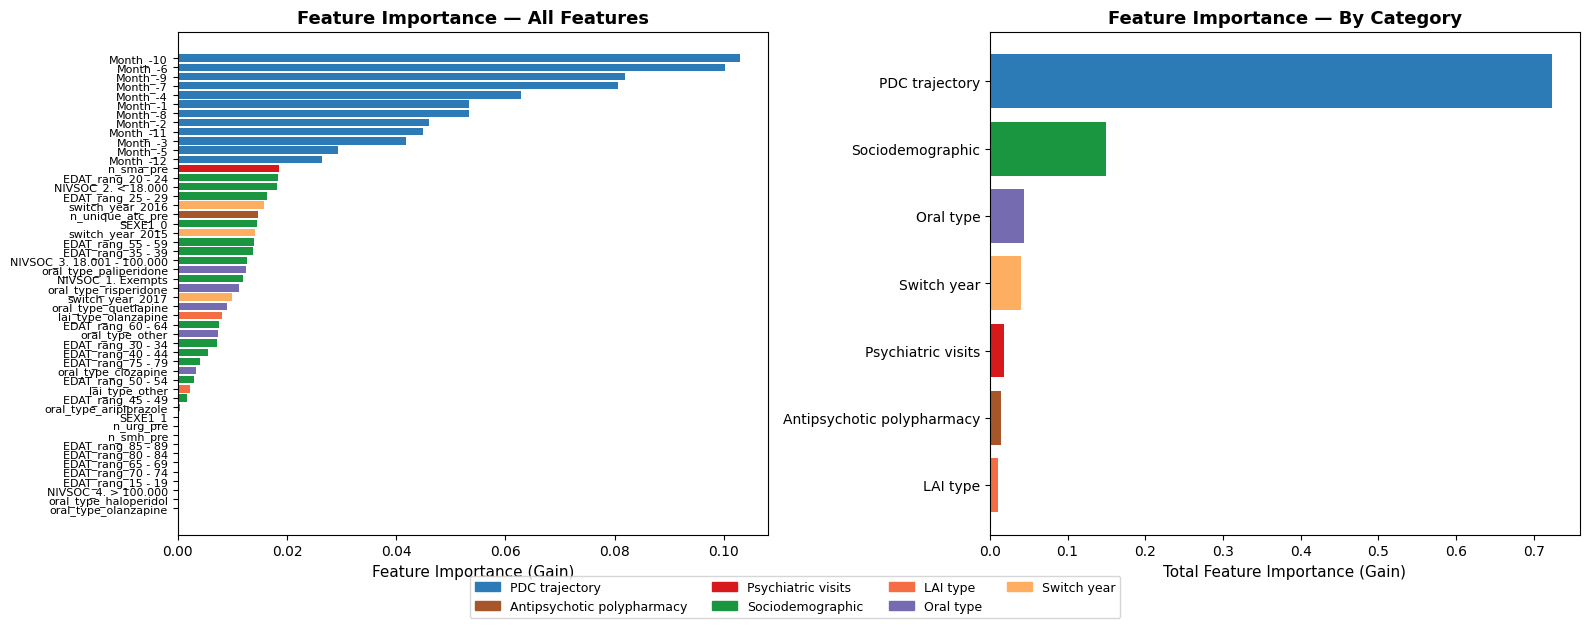

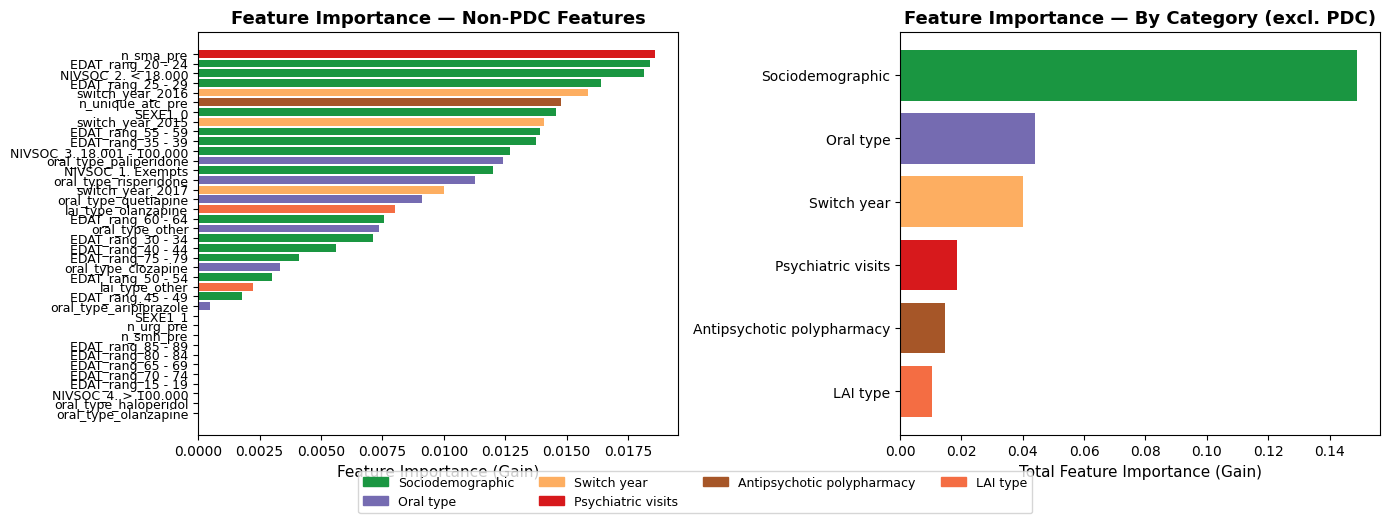


n_unique_atc_pre importance: 0.014775
n_sma_pre             0.018604
EDAT_rang_20 - 24     0.018390
NIVSOC_2. < 18.000    0.018131
EDAT_rang_25 - 29     0.016410
switch_year_2016      0.015879
n_unique_atc_pre      0.014775
SEXE1_0               0.014576
switch_year_2015      0.014085
EDAT_rang_55 - 59     0.013918
EDAT_rang_35 - 39     0.013743
dtype: float32


In [117]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# XGBoost feature importance (gain-based, default for XGBoost)
model = final_pipe.named_steps['model']
feat_names = X.columns.tolist()
importances = model.feature_importances_  # XGBoost uses gain by default
fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)

def categorize(feat):
    if feat.startswith('Month_'):          return 'PDC trajectory'
    elif feat.startswith('n_unique'):      return 'Antipsychotic polypharmacy'
    elif feat.startswith('n_'):            return 'Psychiatric visits'
    elif feat.startswith('SEXE'):          return 'Sociodemographic'
    elif feat.startswith('EDAT'):          return 'Sociodemographic'
    elif feat.startswith('NIVSOC'):        return 'Sociodemographic'
    elif feat.startswith('lai_type'):      return 'LAI type'
    elif feat.startswith('oral_type'):     return 'Oral type'
    elif feat.startswith('switch_year'):   return 'Switch year'
    else:                                  return 'Other'

color_map = {
    'PDC trajectory':             '#2c7bb6',
    'Antipsychotic polypharmacy': '#a65628',
    'Psychiatric visits':         '#d7191c',
    'Sociodemographic':           '#1a9641',
    'LAI type':                   '#f46d43',
    'Oral type':                  '#756bb1',
    'Switch year':                '#fdae61',
    'Other':                      '#bdbdbd'
}

categories = [categorize(f) for f in fi.index]
colors = [color_map[c] for c in categories]

# ── Plot 1: all features ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(fi.index[::-1], fi.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Feature Importance (Gain)', fontsize=11)
axes[0].set_title('Feature Importance — All Features', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)

cat_importance = fi.groupby([categorize(f) for f in fi.index]).sum().sort_values(ascending=False)
bar_colors = [color_map[c] for c in cat_importance.index]
axes[1].barh(cat_importance.index[::-1], cat_importance.values[::-1], color=bar_colors[::-1])
axes[1].set_xlabel('Total Feature Importance (Gain)', fontsize=11)
axes[1].set_title('Feature Importance — By Category', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=10)

patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items() if k in categories]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('feature_importance_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: non-PDC features only ─────────────────────────────────────────────
fi_no_pdc = fi[~fi.index.str.startswith('Month_')]
cats_no_pdc = [categorize(f) for f in fi_no_pdc.index]
colors_no_pdc = [color_map[c] for c in cats_no_pdc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(fi_no_pdc.index[::-1], fi_no_pdc.values[::-1], color=colors_no_pdc[::-1])
axes[0].set_xlabel('Feature Importance (Gain)', fontsize=11)
axes[0].set_title('Feature Importance — Non-PDC Features', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=9)

cat_no_pdc = fi_no_pdc.groupby(cats_no_pdc).sum().sort_values(ascending=False)
axes[1].barh(cat_no_pdc.index[::-1], cat_no_pdc.values[::-1],
             color=[color_map[c] for c in cat_no_pdc.index][::-1])
axes[1].set_xlabel('Total Feature Importance (Gain)', fontsize=11)
axes[1].set_title('Feature Importance — By Category (excl. PDC)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=10)

patches = [mpatches.Patch(color=color_map[c], label=c) for c in cat_no_pdc.index]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('feature_importance_no_pdc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nn_unique_atc_pre importance: {fi['n_unique_atc_pre']:.6f}")
print(fi_no_pdc.head(10))

In [118]:
features.to_csv(r'C:\\Users\\laiar\\Desktop\\Classe IDIBAPS\\data_sintetica\\Data-sintetica\\Data-sintetica\\src\\csv merged\\features_model.csv', index=False)

In [98]:
final_pipe.named_steps['model']

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


PermutationExplainer explainer: 1026it [01:13, 12.06it/s]                          


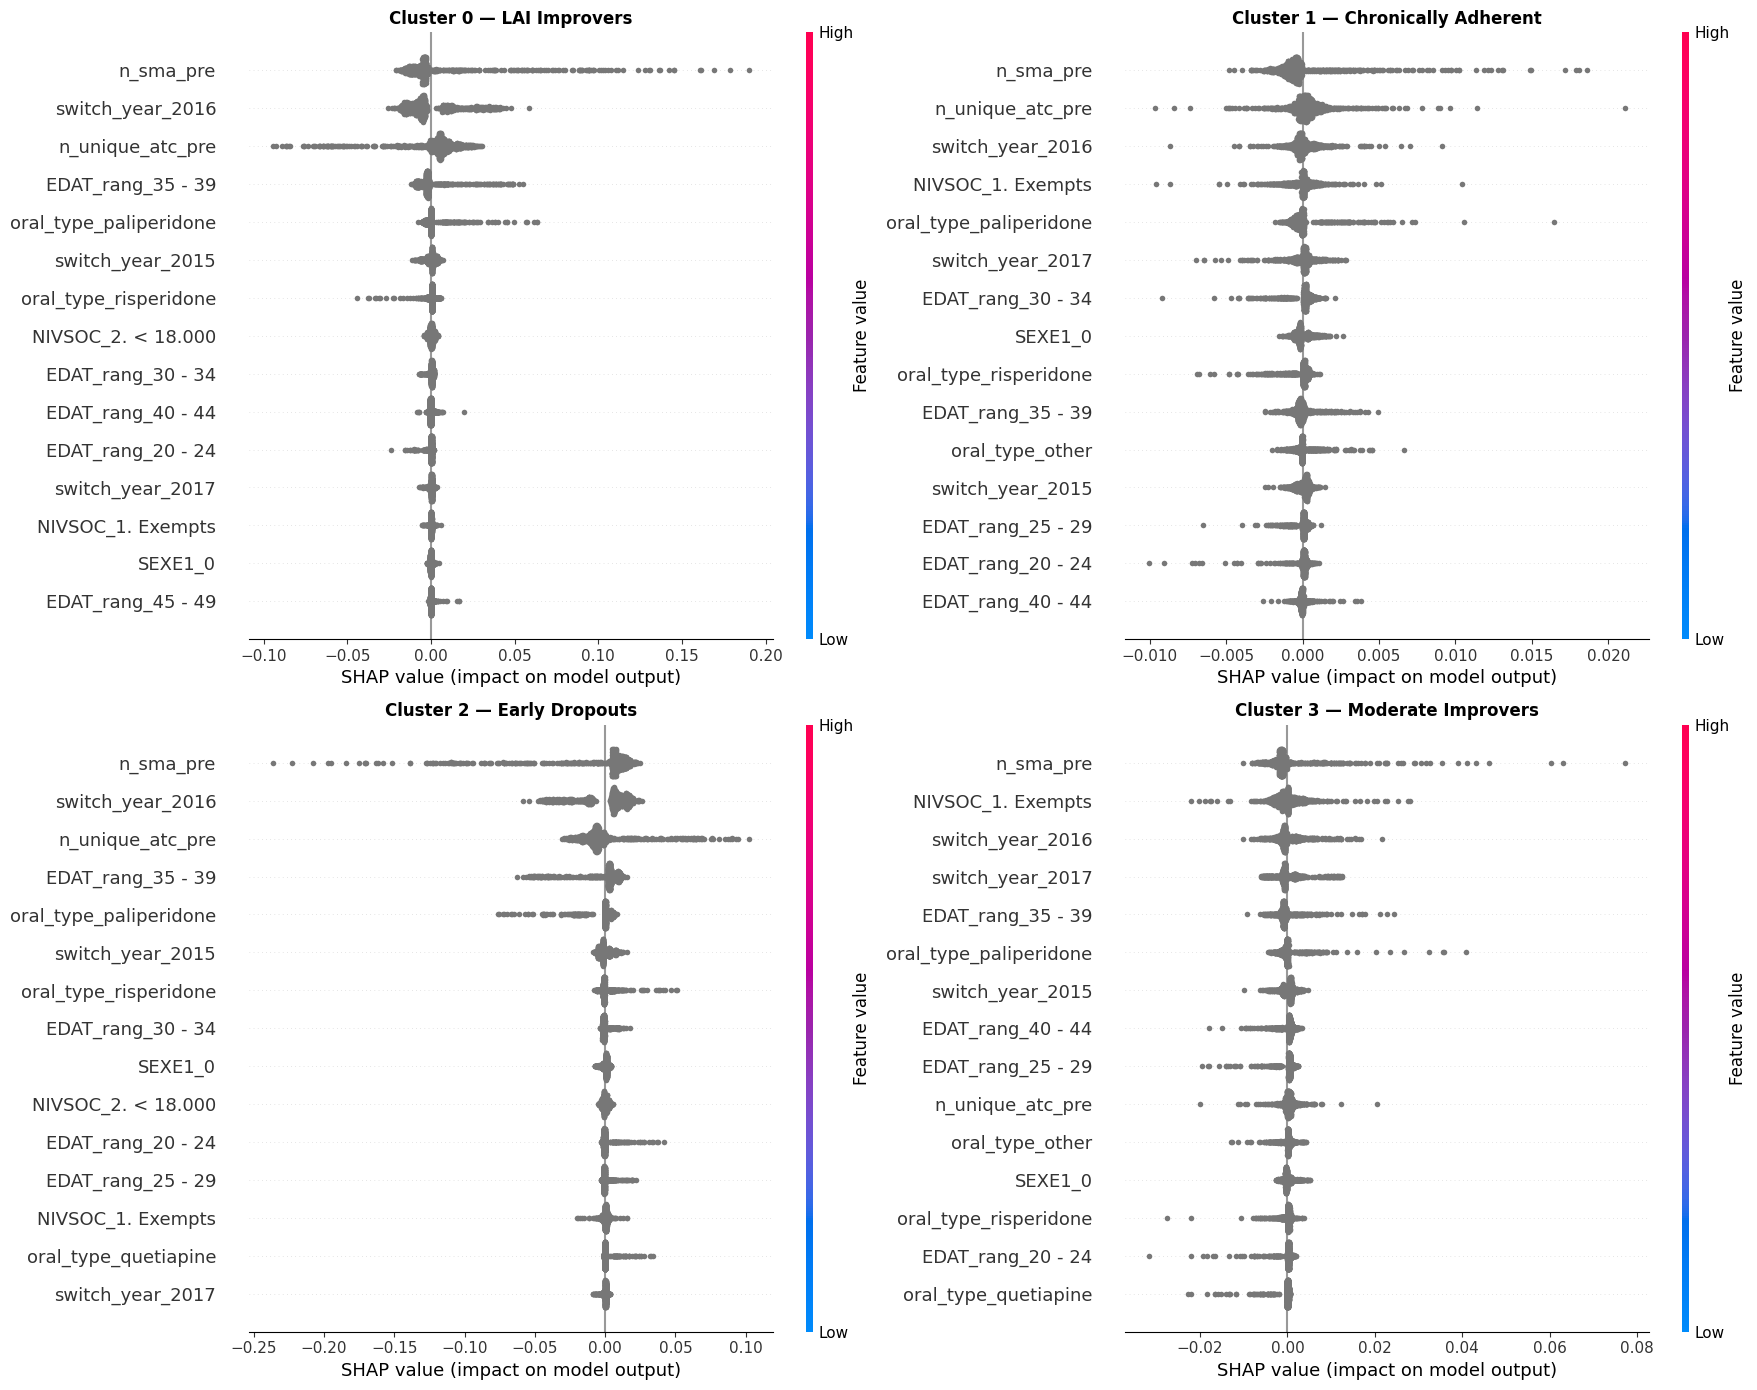

In [131]:
import shap

model = final_pipe.named_steps['model']
X_df = pd.DataFrame(X_arr, columns=X.columns.tolist())

X_transformed = final_pipe[:-1].transform(X_df)
X_transformed_df = pd.DataFrame(X_transformed, columns=X.columns.tolist())

explainer = shap.Explainer(final_pipe[-1].predict_proba, X_transformed_df)
shap_values = explainer(X_transformed_df)

non_pdc_cols = [c for c in X.columns if not c.startswith('Month_')]
non_pdc_idx  = [X.columns.tolist().index(c) for c in non_pdc_cols]
X_no_pdc     = X_df[non_pdc_cols]

cluster_names = {
    0: 'Cluster 0 — LAI Improvers',
    1: 'Cluster 1 — Chronically Adherent',
    2: 'Cluster 2 — Early Dropouts',
    3: 'Cluster 3 — Moderate Improvers'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (cluster_id, name) in enumerate(cluster_names.items()):
    if isinstance(shap_values, list):
        shap_cluster = shap_values[cluster_id]
    else:
        shap_cluster = shap_values[:, :, cluster_id]

    shap_no_pdc = shap_cluster[:, non_pdc_idx]
    plt.sca(axes[i])
    shap.summary_plot(
        shap_no_pdc,
        X_no_pdc,
        show=False,
        plot_size=None,
        max_display=15
    )
    axes[i].set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# Descriptive table for every cluster

In [134]:
from scipy.stats import chi2_contingency, kruskal
import warnings
warnings.filterwarnings('ignore')

# ── Rebuild original (non-dummified) features with cluster label ──────────────
char_df = pdc[['idCas', 'cluster_k4']].copy()
char_df = char_df.merge(switch_info[['idCas', 'switch_year']], on='idCas', how='left')
char_df = char_df.merge(socio[['idCas', 'SEXE1', 'EDAT_rang', 'NIVSOC']], on='idCas', how='left')
char_df = char_df.merge(first_lai[['idCas', 'lai_type']], on='idCas', how='left')
char_df = char_df.merge(most_common_oral[['idCas', 'oral_type']], on='idCas', how='left')
char_df = char_df.merge(polypharmacy, on='idCas', how='left')
for counts in [urg_counts, smh_counts, sma_counts]:
    char_df = char_df.merge(counts, on='idCas', how='left')
char_df[['n_urg_pre', 'n_smh_pre', 'n_sma_pre', 'n_unique_atc_pre']] = \
    char_df[['n_urg_pre', 'n_smh_pre', 'n_sma_pre', 'n_unique_atc_pre']].fillna(0)

cluster_labels = {
    0: 'LAI Improvers',
    1: 'Chronically Adherent',
    2: 'Early Dropouts',
    3: 'Moderate Improvers'
}
char_df['cluster_name'] = char_df['cluster_k4'].map(cluster_labels)
clusters = [0, 1, 2, 3]

rows = []

# ── Categorical variables ─────────────────────────────────────────────────────
cat_vars = {
    'Sex':              'SEXE1',
    'Age range':        'EDAT_rang',
    'Socioeconomic level': 'NIVSOC',
    'Oral type':        'oral_type',
    'LAI type':         'lai_type',
    'Switch year':      'switch_year'
}

for label, col in cat_vars.items():
    categories = sorted(char_df[col].dropna().unique())
    # Chi-square test
    ct = pd.crosstab(char_df[col], char_df['cluster_k4'])
    chi2, p, _, _ = chi2_contingency(ct)

    for cat in categories:
        row = {'Variable': label, 'Category': str(cat), 'p-value': f'{p:.3f}' if cat == categories[0] else ''}
        for c in clusters:
            subset = char_df[char_df['cluster_k4'] == c]
            n = (subset[col] == cat).sum()
            pct = 100 * n / len(subset)
            row[cluster_labels[c]] = f'{n} ({pct:.1f}%)'
        rows.append(row)

# ── Continuous variables ──────────────────────────────────────────────────────
cont_vars = {
    'Pre-switch outpatient visits':      'n_sma_pre',
    'Pre-switch hospitalizations':       'n_smh_pre',
    'Pre-switch emergency visits':       'n_urg_pre',
    'Antipsychotic polypharmacy (n ATC)':'n_unique_atc_pre'
}

for label, col in cont_vars.items():
    groups = [char_df[char_df['cluster_k4'] == c][col].values for c in clusters]
    try:
        stat, p = kruskal(*groups)
        p_str = f'{p:.3f}'
    except ValueError:
        p_str = 'n/a'

    row = {'Variable': label, 'Category': 'Median (IQR)', 'p-value': p_str}
    for c, g in zip(clusters, groups):
        med = np.median(g)
        q1, q3 = np.percentile(g, 25), np.percentile(g, 75)
        row[cluster_labels[c]] = f'{med:.1f} ({q1:.1f}–{q3:.1f})'
    rows.append(row)

# ── Build and display table ───────────────────────────────────────────────────
table = pd.DataFrame(rows, columns=[
    'Variable', 'Category',
    'LAI Improvers', 'Chronically Adherent', 'Early Dropouts', 'Moderate Improvers',
    'p-value'
])

# Add n per cluster as header info
n_per_cluster = char_df['cluster_k4'].value_counts().sort_index()
print("N per cluster:")
for c in clusters:
    print(f"  {cluster_labels[c]}: n={n_per_cluster[c]}")

print("\n")
print(table.to_string(index=False))

# Save to CSV
table.to_csv('cluster_characterisation_table.csv', index=False)
print("\nSaved to cluster_characterisation_table.csv")

N per cluster:
  LAI Improvers: n=321
  Chronically Adherent: n=319
  Early Dropouts: n=187
  Moderate Improvers: n=198


                          Variable            Category LAI Improvers Chronically Adherent Early Dropouts Moderate Improvers p-value
                               Sex                   0   222 (69.2%)          230 (72.1%)    129 (69.0%)        129 (65.2%)   0.426
                               Sex                   1    99 (30.8%)           89 (27.9%)     58 (31.0%)         69 (34.8%)        
                         Age range             15 - 19      0 (0.0%)             2 (0.6%)       1 (0.5%)           0 (0.0%)   0.016
                         Age range             20 - 24     27 (8.4%)            19 (6.0%)      16 (8.6%)           7 (3.5%)        
                         Age range             25 - 29    45 (14.0%)            14 (4.4%)     27 (14.4%)         22 (11.1%)        
                         Age range             30 - 34    38 (11.8%)           32 (10.

In [135]:
cluster_labels = {
    0: 'Cluster 0 — LAI Improvers',
    1: 'Cluster 1 — Chronically Adherent',
    2: 'Cluster 2 — Early Dropouts',
    3: 'Cluster 3 — Moderate Improvers'
}

cat_vars = {
    'Sex':                 'SEXE1',
    'Age range':           'EDAT_rang',
    'Socioeconomic level': 'NIVSOC',
    'Oral type':           'oral_type',
    'LAI type':            'lai_type',
    'Switch year':         'switch_year'
}

cont_vars = {
    'Pre-switch outpatient visits':       'n_sma_pre',
    'Pre-switch hospitalizations':        'n_smh_pre',
    'Pre-switch emergency visits':        'n_urg_pre',
    'Antipsychotic polypharmacy (n ATC)': 'n_unique_atc_pre'
}

all_tables = {}

for cluster_id, cluster_name in cluster_labels.items():
    subset = char_df[char_df['cluster_k4'] == cluster_id]
    n_total = len(subset)
    rows = []

    # Categorical
    for label, col in cat_vars.items():
        categories = sorted(char_df[col].dropna().unique())
        for cat in categories:
            n = (subset[col] == cat).sum()
            pct = 100 * n / n_total
            rows.append({'Variable': label, 'Category': str(cat), 'n (%)': f'{n} ({pct:.1f}%)'})

    # Continuous
    for label, col in cont_vars.items():
        vals = subset[col].values
        med = np.median(vals)
        q1, q3 = np.percentile(vals, 25), np.percentile(vals, 75)
        rows.append({'Variable': label, 'Category': 'Median (IQR)', 'n (%)': f'{med:.1f} ({q1:.1f}–{q3:.1f})'})

    table = pd.DataFrame(rows)
    all_tables[cluster_name] = table

    print(f"\n{'='*55}")
    print(f"  {cluster_name}  (n={n_total})")
    print(f"{'='*55}")
    print(table.to_string(index=False))

    table.to_csv(f'table_{cluster_name.replace(" ", "_").replace("—","").replace("  ","_")}.csv', index=False)


  Cluster 0 — LAI Improvers  (n=321)
                          Variable            Category         n (%)
                               Sex                   0   222 (69.2%)
                               Sex                   1    99 (30.8%)
                         Age range             15 - 19      0 (0.0%)
                         Age range             20 - 24     27 (8.4%)
                         Age range             25 - 29    45 (14.0%)
                         Age range             30 - 34    38 (11.8%)
                         Age range             35 - 39    55 (17.1%)
                         Age range             40 - 44    47 (14.6%)
                         Age range             45 - 49    33 (10.3%)
                         Age range             50 - 54     27 (8.4%)
                         Age range             55 - 59     18 (5.6%)
                         Age range             60 - 64     12 (3.7%)
                         Age range             65 - 69      6 (1.

In [137]:
summary_rows = []

for cluster_id, cluster_name in cluster_labels.items():
    subset = char_df[char_df['cluster_k4'] == cluster_id]
    n_total = len(subset)
    
    row = {'Cluster': cluster_name, 'N': n_total}
    
    # Sex
    pct_male = 100 * (subset['SEXE1'] == 1).sum() / n_total
    row['Male (%)'] = f'{pct_male:.1f}%'
    
    # Age
    # Extract numeric midpoint from range string for median
    age_mid = subset['EDAT_rang'].str.extract(r'(\d+)').astype(float)
    row['Median age range'] = subset['EDAT_rang'].value_counts().idxmax()
    
    # NIVSOC counts
    for nivsoc in sorted(char_df['NIVSOC'].dropna().unique()):
        n = (subset['NIVSOC'] == nivsoc).sum()
        pct = 100 * n / n_total
        row[f'NIVSOC {nivsoc}'] = f'{n} ({pct:.1f}%)'
    
    # Oral type most common
    row['Main oral type'] = subset['oral_type'].value_counts().idxmax()
    
    # LAI type most common
    row['Main LAI type'] = subset['lai_type'].value_counts().idxmax()
    
    # Switch year most common
    row['Main switch year'] = subset['switch_year'].value_counts().idxmax()
    
    # Polypharmacy
    med = np.median(subset['n_unique_atc_pre'].values)
    q1, q3 = np.percentile(subset['n_unique_atc_pre'].values, 25), np.percentile(subset['n_unique_atc_pre'].values, 75)
    row['Antipsychotic polypharmacy'] = f'{med:.1f} ({q1:.1f}–{q3:.1f})'
    
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index('Cluster').T
print(summary.to_string())
summary.to_csv('cluster_summary_table.csv')

Cluster                    Cluster 0 — LAI Improvers Cluster 1 — Chronically Adherent Cluster 2 — Early Dropouts Cluster 3 — Moderate Improvers
N                                                321                              319                        187                            198
Male (%)                                       30.8%                            27.9%                      31.0%                          34.8%
Median age range                             35 - 39                          40 - 44                    40 - 44                        40 - 44
NIVSOC 1. Exempts                        147 (45.8%)                      163 (51.1%)                 81 (43.3%)                     92 (46.5%)
NIVSOC 2. < 18.000                       154 (48.0%)                      145 (45.5%)                101 (54.0%)                    101 (51.0%)
NIVSOC 3. 18.001 - 100.000                 18 (5.6%)                        10 (3.1%)                   5 (2.7%)                       5

# Plotting all Oral / LAI drug forms with their PDC lines

In [139]:
print(plot_df['oral_type'].value_counts())
print(plot_df['lai_type'].value_counts())

oral_type
aripiprazole    268
other           204
risperidone     175
olanzapine      158
paliperidone    102
quetiapine       64
haloperidol      31
clozapine        23
Name: count, dtype: int64
lai_type
other         83
olanzapine    13
Name: count, dtype: int64


In [140]:
print(first_lai['lai_type'].value_counts())
print(first_lai['first_lai_product'].value_counts().head(20))

lai_type
other          33260
olanzapine       137
haloperidol        4
Name: count, dtype: int64
first_lai_product
MIRENA 20MCG/24 HORAS SISTEMA DE LIBERACION INTRAUTERINO 1 DISPOSITIVO                      6389
TRUVADA 200/245MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA                                   2359
HUMIRA 40MG 2 PLUMAS PRECARGADAS 0,8ML SOLUCION INYECTABLE                                  1087
ATRIPLA 600/200/245MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA                               1011
ISENTRESS 400MG 60 COMPRIMIDOS RECUBIERTOS CON PELICULA                                      773
MAVIRET 100/40MG 84 COMPRIMIDOS RECUBIERTOS CON PELICULA                                     744
REMICADE 100 MG POLVO PARA CONCENTRADO PARA SOLUCION PARA PERFUSION, 1 vial                  737
EPCLUSA 400/100MG 28 COMPRIMIDOS RECUBIERTOS CON PELICULA                                    650
KIVEXA 600/300 30 COMPRIMIDOS RECUBIERTOS CON PELICULA                                       622
STRIBILD 15

In [141]:
# Filter t25 to antipsychotics only (N05A*)
t25_ap = t25[t25['(HIS) Subgrup 7 (ATC)'].str.startswith('N05A', na=False)]

# Then get first LAI per patient
first_lai = (
    t25_ap.sort_values('Any_Mes')
    .groupby('idCas').first()
    .reset_index()[['idCas', '(HIS) Producte Desc']]
)
first_lai.columns = ['idCas', 'first_lai_product']
first_lai['lai_type'] = first_lai['first_lai_product'].apply(classify_lai)

print(first_lai['lai_type'].value_counts())
print(first_lai['first_lai_product'].value_counts().head(20))

lai_type
other          1621
olanzapine      144
haloperidol       4
Name: count, dtype: int64
first_lai_product
DECENTAN 8 mg miligramo(s) 50 Comprimido.                                                       413
MODECATE 25 MG/ML  5 AMPOLLAS Solución inyectable. /CSE 013284                                  332
PERPHENAZIN NEURAXPHARM 8 mg miligramo(s) 100 Comprimido                                        310
PERPHENAZIN-NEURAXPHARM 8 MG  50 COMP/ CSE012538                                                174
FLUPHENAZIN-NEURAXPHARM D 5 AMPOLLAS 25 mg/ml  5 Sol inyect/CSE013285                           173
FLUPHENAZIN-NEURAXPHARM D 25 mg/ml 5 AMPOLLES Solució injectable                                 83
ZYPADHERA 300MG 1 VIAL POLVO + 1 VIAL DISOLV SUSP INY LIBERAC PROLONG                            82
FLUPHENAZIN-NEURAXPHARM D 5 AMPOLLAS DE 50 MG/0,5ML(100 mg/ml) 5 Sol inyectable/ CSE013570       42
ZYPADHERA 405MG 1 VIAL POLVO + 1 VIAL DISOLV SUSP INY LIBERAC PROLONG                  

In [142]:
def classify_lai(name):
    name = str(name).upper()
    if 'XEPLION' in name or 'TREVICTA' in name or 'INVEGA' in name:     return 'paliperidone'
    elif 'ABILIFY MAINTENA' in name:                                      return 'aripiprazole'
    elif 'RISPERDAL CONSTA' in name:                                      return 'risperidone'
    elif 'ZYPADHERA' in name:                                             return 'olanzapine'
    elif 'HALDOL' in name or 'HALDOL DEPOT' in name or 'HALDOL DECANOAS' in name: return 'haloperidol'
    elif 'MODECATE' in name or 'FLUPHENAZIN' in name:                    return 'fluphenazine'
    elif 'DECENTAN' in name or 'PERPHENAZIN' in name:                    return 'perphenazine'
    elif 'CLOPIXOL' in name:                                              return 'zuclopenthixol'
    elif 'FLUANXOL' in name:                                              return 'flupentixol'
    else:                                                                  return 'other'

# Re-apply
first_lai['lai_type'] = first_lai['first_lai_product'].apply(classify_lai)
print(first_lai['lai_type'].value_counts())

lai_type
perphenazine    897
fluphenazine    687
olanzapine      144
other            37
haloperidol       4
Name: count, dtype: int64


In [143]:
# Filter t25_ap to within the switch window per patient
t25_ap_cohort = t25_ap.merge(switch_dates, on='idCas', how='inner')
t25_ap_cohort = t25_ap_cohort[
    (t25_ap_cohort['Any_Mes'] >= t25_ap_cohort['first_lai_date'] - pd.DateOffset(months=1)) &
    (t25_ap_cohort['Any_Mes'] <= t25_ap_cohort['first_lai_date'] + pd.DateOffset(months=3))
]

first_lai = (
    t25_ap_cohort.sort_values('Any_Mes')
    .groupby('idCas').first()
    .reset_index()[['idCas', '(HIS) Producte Desc']]
)
first_lai.columns = ['idCas', 'first_lai_product']
first_lai['lai_type'] = first_lai['first_lai_product'].apply(classify_lai)
print(first_lai['lai_type'].value_counts())

lai_type
olanzapine      13
fluphenazine     2
perphenazine     1
Name: count, dtype: int64


In [144]:
# How many cohort patients appear in t25_ap at all?
print(t25_ap[t25_ap['idCas'].isin(pdc['idCas'])]['(HIS) Producte Desc'].value_counts().head(20))

(HIS) Producte Desc
ZYPADHERA 300MG 1 VIAL POLVO + 1 VIAL DISOLV SUSP INY LIBERAC PROLONG                           118
ZYPADHERA 405MG 1 VIAL POLVO + 1 VIAL DISOLV SUSP INY LIBERAC PROLONG                            81
ZYPADHERA 210MG 1 VIAL POLVO + 1 VIAL DISOLV SUSP INY LIBERAC PROLONG                            38
MODECATE 25 MG/ML  5 AMPOLLAS Solución inyectable. /CSE 013284                                   12
FLUPHENAZIN-NEURAXPHARM D 25 mg/ml 5 AMPOLLES Solució injectable                                 10
FLUPHENAZIN-NEURAXPHARM D 5 AMPOLLAS 25 mg/ml  5 Sol inyect/CSE013285                            10
PERPHENAZIN NEURAXPHARM 8 mg miligramo(s) 100 Comprimido                                          7
PERPHENAZIN-NEURAXPHARM 8 MG  50 COMP/ CSE012538                                                  7
FLUPHENAZIN-NEURAXPHARM D 5 AMPOLLAS DE 50 MG/0,5ML(100 mg/ml) 5 Sol inyectable/ CSE013570        5
FLUPHENAZIN-NEURAXPHARM D 5 AMPOLLAS DE 12,5 MG/0,5ML (25 mg/ml) 5 Sol inyectabl

In [145]:
print(t23[t23['idCas'].isin(pdc['idCas'])]['DES_HIS_Producte'].value_counts().head(20))

DES_HIS_Producte
ABILIFY MAINTENA 400MG 1 VIAL POLVO +1 VIAL DISOLV SUSPENS LIBER PROLONG    20784
XEPLION 150MG 1 JERINGA PRECARG 1,5ML SUSPEN INYEC LIBERAC PROLONG          13654
XEPLION 100MG 1 JERINGA PRECARG 1ML SUSPENS INYEC LIBERAC PROLONG           11088
ABILIFY MAINTENA 300MG 1 VIAL POLVO +1 VIAL DISOLV SUSPENS LIBER PROLONG     4747
XEPLION 75MG 1 JERINGA PRECARG 0,75ML SUSPEN INYEC LIBERAC PROLONG           4326
ABILIFY 15MG 28 COMPRIMIDOS                                                  3814
ABILIFY 10MG 28 COMPRIMIDOS                                                  3026
INVEGA 6MG 28 COMPRIMIDOS DE LIBERACION PROLONGADA                           2896
XEPLION 50MG 1 JERINGA PRECARG 0,5ML SUSPEN INYEC LIBERAC PROLONG            2752
RISPERDAL CONSTA 50MG/VIAL 1 VIAL + 1 JER PRECARG                            2566
NEMEA 100MG 40 COMPRIMIDOS EFG                                               2534
INVEGA 9MG 28 COMPRIMIDOS DE LIBERACION PROLONGADA                           2118

In [146]:
# LAIs from t23 (community pharmacy)
lai_products_t23 = ['ABILIFY MAINTENA', 'XEPLION', 'RISPERDAL CONSTA', 'TREVICTA', 'INVEGA SUSTENNA', 'INVEGA TRINZA']

t23_full = pd.read_csv(r'C:\Users\laiar\Desktop\DATOS_PADRIS_nets\23_antipsicotics_dispensats.csv', low_memory=False)
t23_full['Any_Mes'] = pd.to_datetime(t23_full['Any_Mes'], format='%Y%m')

# Filter to cohort patients only
t23_lai = t23_full[t23_full['idCas'].isin(pdc['idCas'])].copy()

# Keep only LAI products
mask = t23_lai['DES_HIS_Producte'].str.upper().apply(
    lambda x: any(p in x for p in lai_products_t23)
)
t23_lai = t23_lai[mask][['idCas', 'Any_Mes', 'DES_HIS_Producte']]
t23_lai.columns = ['idCas', 'Any_Mes', 'first_lai_product']

# LAIs from t25 (hospital dispensing) — ZYPADHERA
t25_lai = t25_ap[t25_ap['idCas'].isin(pdc['idCas'])][['idCas', 'Any_Mes', '(HIS) Producte Desc']].copy()
t25_lai.columns = ['idCas', 'Any_Mes', 'first_lai_product']

# Combine and get first LAI per patient
all_lai = pd.concat([t23_lai, t25_lai], ignore_index=True)
all_lai = all_lai.merge(switch_dates, on='idCas', how='inner')
all_lai = all_lai[
    (all_lai['Any_Mes'] >= all_lai['first_lai_date'] - pd.DateOffset(months=1)) &
    (all_lai['Any_Mes'] <= all_lai['first_lai_date'] + pd.DateOffset(months=3))
]

first_lai = (
    all_lai.sort_values('Any_Mes')
    .groupby('idCas').first()
    .reset_index()[['idCas', 'first_lai_product']]
)
first_lai['lai_type'] = first_lai['first_lai_product'].apply(classify_lai)
print(first_lai['lai_type'].value_counts())

lai_type
paliperidone    553
aripiprazole    347
risperidone     112
olanzapine       13
Name: count, dtype: int64


In [147]:
# Re-merge lai_type into plot_df
plot_df = pdc[['idCas'] + pre_cols].copy()
plot_df = plot_df.merge(most_common_oral[['idCas', 'oral_type']], on='idCas', how='left')
plot_df = plot_df.merge(first_lai[['idCas', 'lai_type']], on='idCas', how='left')

# Filter out 'other'
oral_types = sorted([o for o in plot_df['oral_type'].dropna().unique() if o != 'other'])
lai_types  = sorted([l for l in plot_df['lai_type'].dropna().unique() if l != 'other'])

print(plot_df['oral_type'].value_counts())
print(plot_df['lai_type'].value_counts())

oral_type
aripiprazole    268
other           204
risperidone     175
olanzapine      158
paliperidone    102
quetiapine       64
haloperidol      31
clozapine        23
Name: count, dtype: int64
lai_type
paliperidone    553
aripiprazole    347
risperidone     112
olanzapine       13
Name: count, dtype: int64


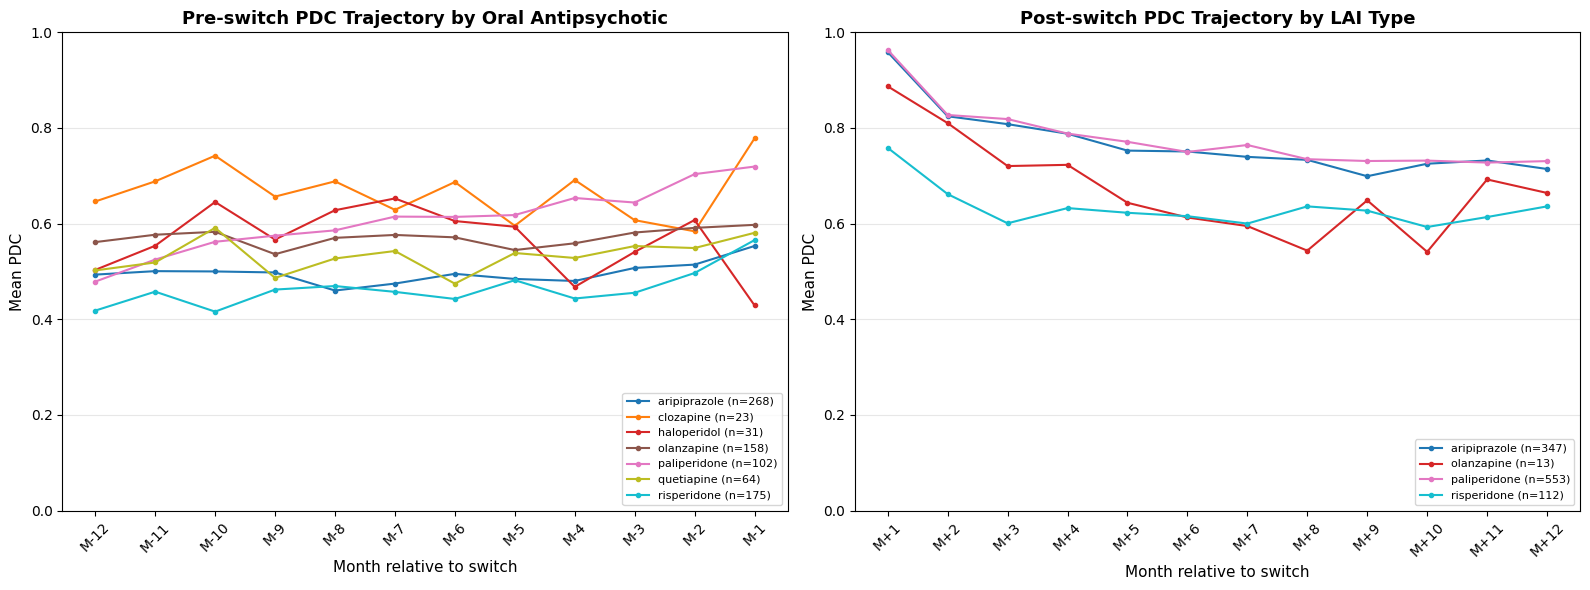

In [149]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

pre_cols  = [f'Month_{i}' for i in range(-12, 0)]
post_cols = [f'Month_{i}' for i in range(1, 13)]
month_labels_pre  = [f'M{i}' for i in range(-12, 0)]
month_labels_post = [f'M+{i}' for i in range(1, 13)]

plot_df = pdc[['idCas'] + pre_cols + post_cols].copy()
plot_df = plot_df.merge(most_common_oral[['idCas', 'oral_type']], on='idCas', how='left')
plot_df = plot_df.merge(first_lai[['idCas', 'lai_type']], on='idCas', how='left')

oral_types = sorted([o for o in plot_df['oral_type'].dropna().unique() if o != 'other'])
lai_types  = sorted([l for l in plot_df['lai_type'].dropna().unique() if l != 'other'])

colors_oral = cm.tab10(np.linspace(0, 1, len(oral_types)))
colors_lai  = cm.tab10(np.linspace(0, 1, len(lai_types)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Oral type — pre-switch ────────────────────────────────────────────
for oral, color in zip(oral_types, colors_oral):
    subset = plot_df[plot_df['oral_type'] == oral]
    mean_traj = subset[pre_cols].mean()
    n = len(subset)
    axes[0].plot(month_labels_pre, mean_traj.values, marker='o', markersize=3,
                 label=f'{oral} (n={n})', color=color)

axes[0].set_title('Pre-switch PDC Trajectory by Oral Antipsychotic', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month relative to switch', fontsize=11)
axes[0].set_ylabel('Mean PDC', fontsize=11)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# ── Plot 2: LAI type — post-switch ────────────────────────────────────────────
for lai, color in zip(lai_types, colors_lai):
    subset = plot_df[plot_df['lai_type'] == lai]
    mean_traj = subset[post_cols].mean()
    n = len(subset)
    axes[1].plot(month_labels_post, mean_traj.values, marker='o', markersize=3,
                 label=f'{lai} (n={n})', color=color)

axes[1].set_title('Post-switch PDC Trajectory by LAI Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month relative to switch', fontsize=11)
axes[1].set_ylabel('Mean PDC', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8, loc='lower right')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pdc_trajectory_by_drug.png', dpi=150, bbox_inches='tight')
plt.show()

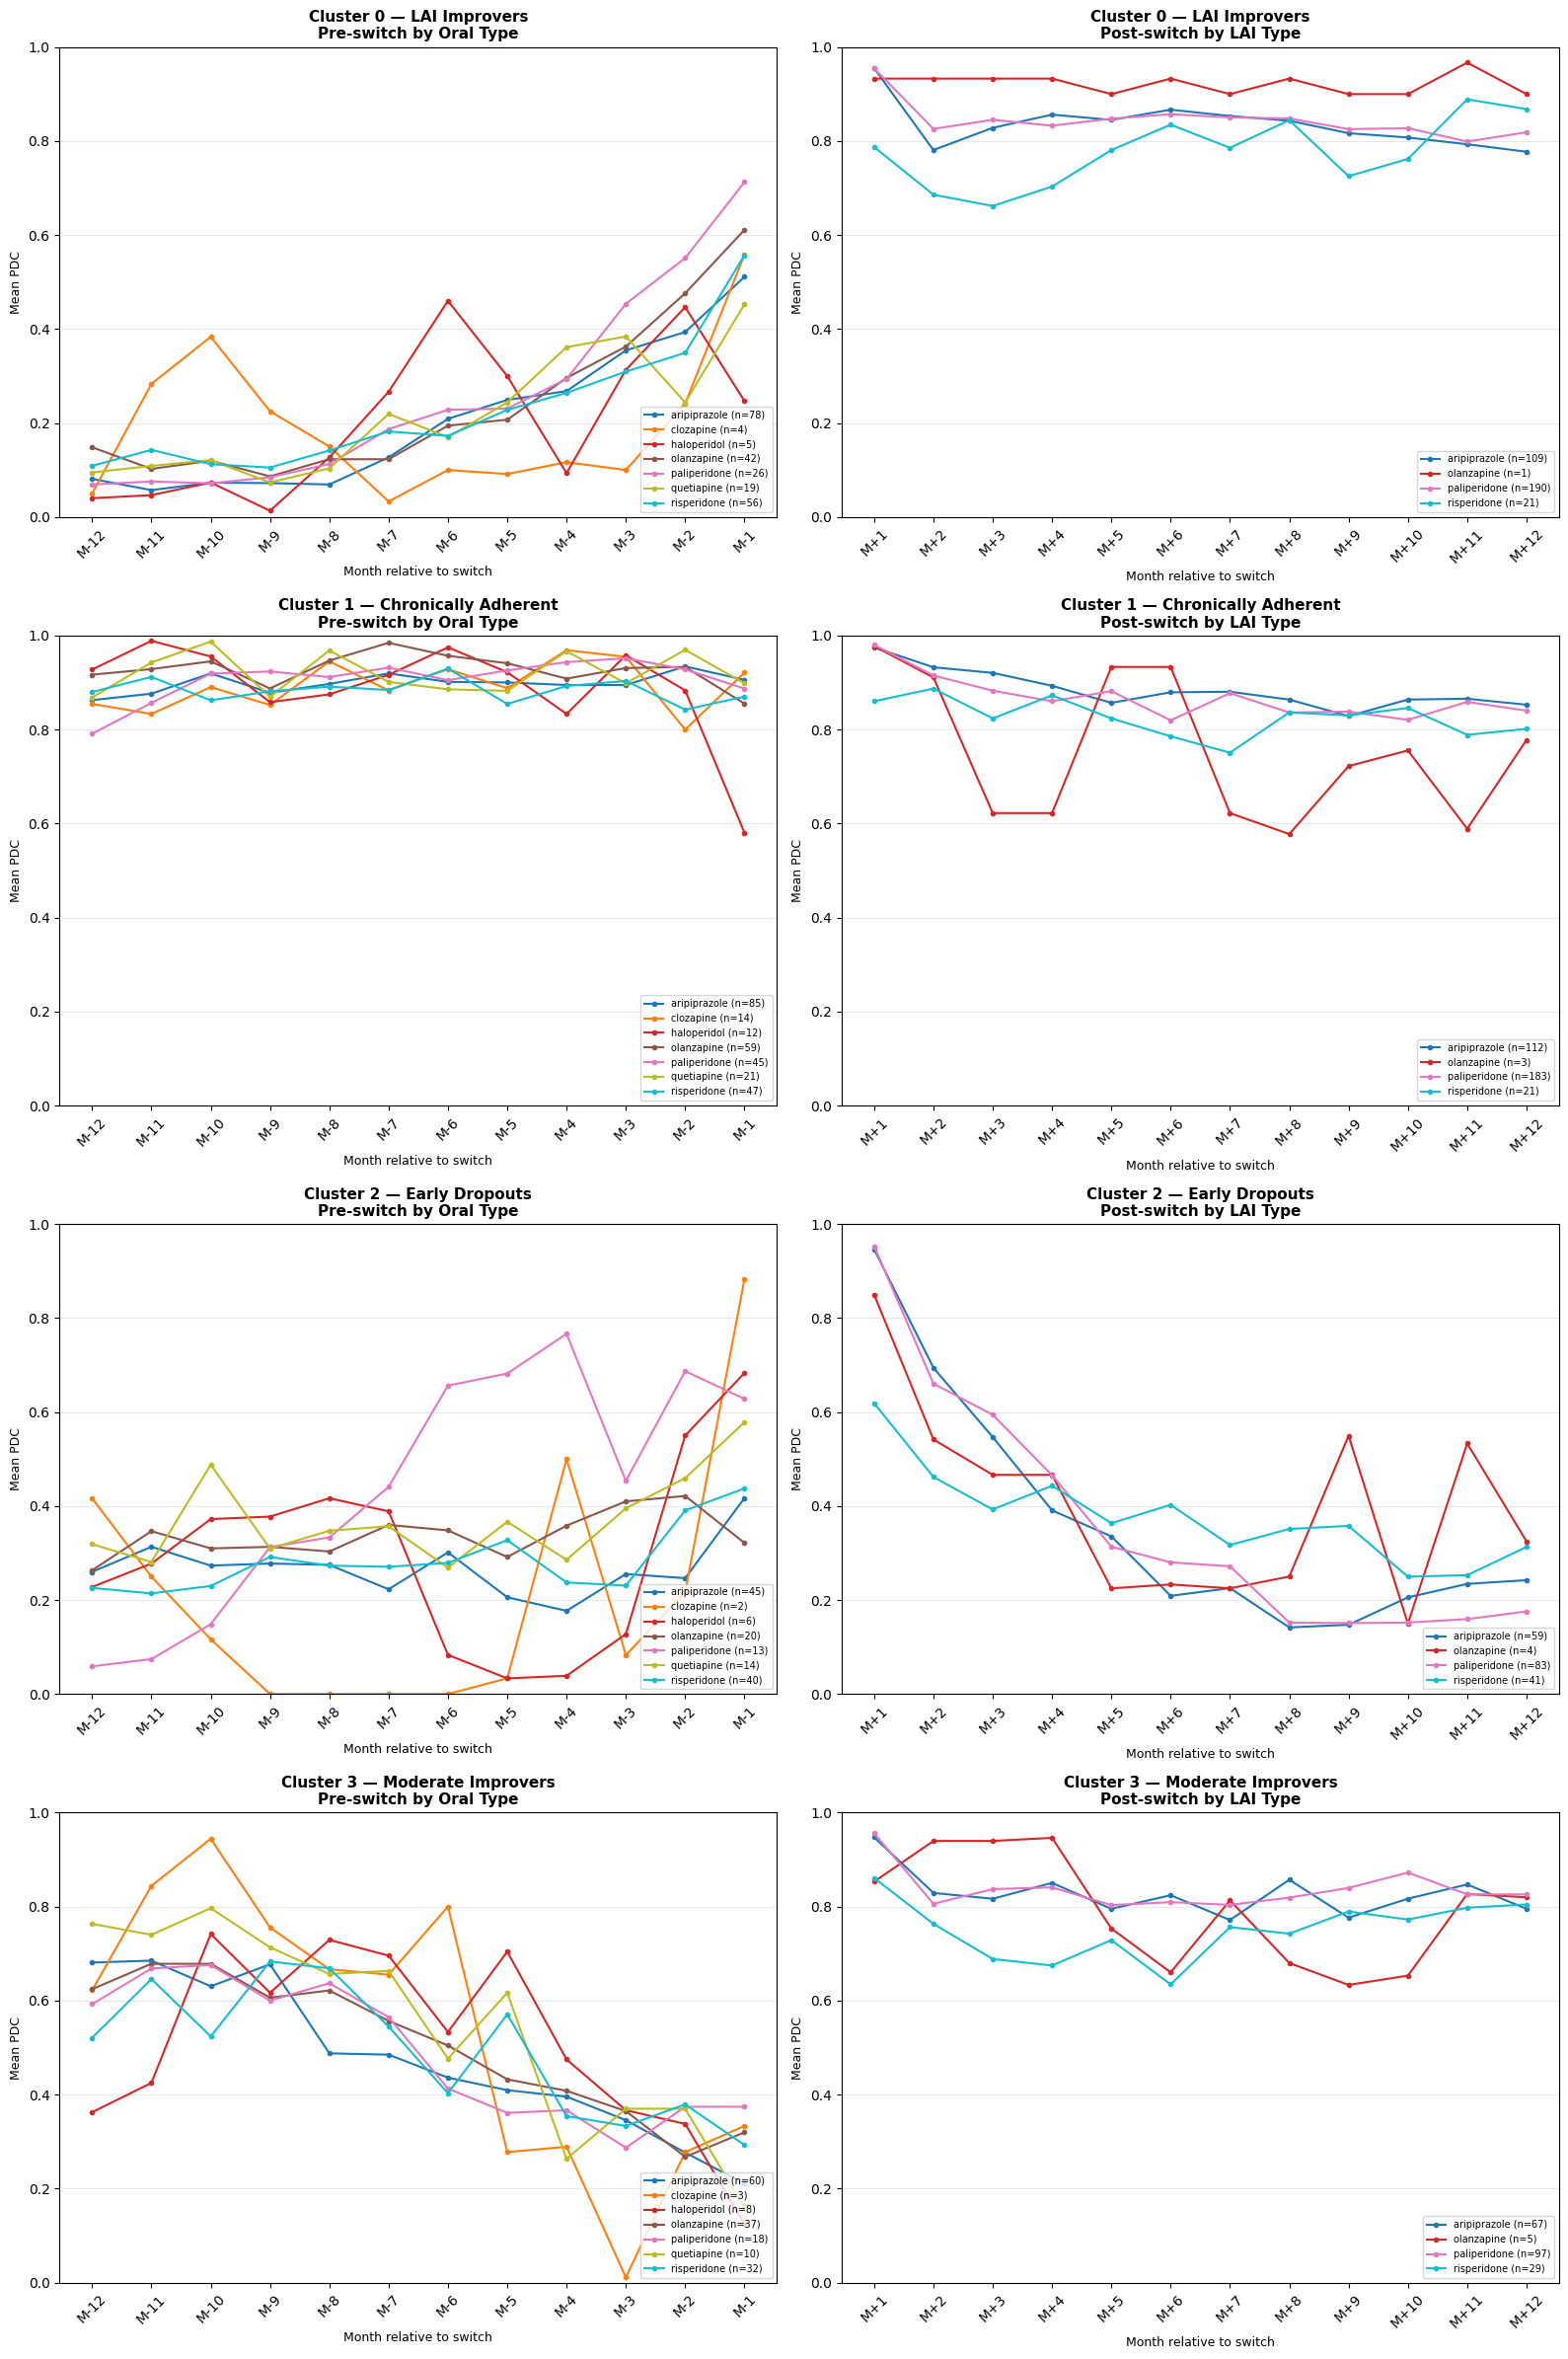

In [150]:
# Per Cluster

fig, axes = plt.subplots(4, 2, figsize=(16, 24))

cluster_names = {
    0: 'Cluster 0 — LAI Improvers',
    1: 'Cluster 1 — Chronically Adherent',
    2: 'Cluster 2 — Early Dropouts',
    3: 'Cluster 3 — Moderate Improvers'
}

# Add cluster to plot_df
plot_df = plot_df.merge(pdc[['idCas', 'cluster_k4']], on='idCas', how='left')

for i, (cluster_id, cluster_name) in enumerate(cluster_names.items()):
    cluster_subset = plot_df[plot_df['cluster_k4'] == cluster_id]

    # ── Left: Oral pre-switch ─────────────────────────────────────────────────
    ax_oral = axes[i, 0]
    colors_oral = cm.tab10(np.linspace(0, 1, len(oral_types)))
    for oral, color in zip(oral_types, colors_oral):
        subset = cluster_subset[cluster_subset['oral_type'] == oral]
        if len(subset) == 0:
            continue
        mean_traj = subset[pre_cols].mean()
        n = len(subset)
        ax_oral.plot(month_labels_pre, mean_traj.values, marker='o', markersize=3,
                     label=f'{oral} (n={n})', color=color)
    ax_oral.set_title(f'{cluster_name}\nPre-switch by Oral Type', fontsize=11, fontweight='bold')
    ax_oral.set_xlabel('Month relative to switch', fontsize=9)
    ax_oral.set_ylabel('Mean PDC', fontsize=9)
    ax_oral.set_ylim(0, 1)
    ax_oral.legend(fontsize=7, loc='lower right')
    ax_oral.tick_params(axis='x', rotation=45)
    ax_oral.grid(axis='y', alpha=0.3)

    # ── Right: LAI post-switch ────────────────────────────────────────────────
    ax_lai = axes[i, 1]
    colors_lai = cm.tab10(np.linspace(0, 1, len(lai_types)))
    for lai, color in zip(lai_types, colors_lai):
        subset = cluster_subset[cluster_subset['lai_type'] == lai]
        if len(subset) == 0:
            continue
        mean_traj = subset[post_cols].mean()
        n = len(subset)
        ax_lai.plot(month_labels_post, mean_traj.values, marker='o', markersize=3,
                    label=f'{lai} (n={n})', color=color)
    ax_lai.set_title(f'{cluster_name}\nPost-switch by LAI Type', fontsize=11, fontweight='bold')
    ax_lai.set_xlabel('Month relative to switch', fontsize=9)
    ax_lai.set_ylabel('Mean PDC', fontsize=9)
    ax_lai.set_ylim(0, 1)
    ax_lai.legend(fontsize=7, loc='lower right')
    ax_lai.tick_params(axis='x', rotation=45)
    ax_lai.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pdc_trajectory_by_drug_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

In [151]:
print([c for c in X.columns if 'Month' in c])

['Month_-12', 'Month_-11', 'Month_-10', 'Month_-9', 'Month_-8', 'Month_-7', 'Month_-6', 'Month_-5', 'Month_-4', 'Month_-3', 'Month_-2', 'Month_-1']


In [152]:
non_switchers = annual[annual['oral_only'] == True][['idCas']].drop_duplicates()
print(f"Non-switchers: {len(non_switchers)}")

Non-switchers: 5662


In [154]:
t23_ns = t23_full[t23_full['idCas'].isin(non_switchers['idCas'])].copy()
print(f"Rows: {len(t23_ns)}")
print(f"Date range: {t23_ns['Any_Mes'].min()} to {t23_ns['Any_Mes'].max()}")
print(f"Patients with dispensing data: {t23_ns['idCas'].nunique()}")

Rows: 512521
Date range: 2010-01-01 00:00:00 to 2019-12-01 00:00:00
Patients with dispensing data: 5662


In [163]:
# ── 0. Reload t23_ns fresh ────────────────────────────────────────────────────
t23_ns = t23_full[t23_full['idCas'].isin(non_switchers['idCas'])][
    ['idCas', 'Any_Mes', 'Nombre_DDD_Receptes_Dispensades']
].copy()

# ── 1. Get last dispensing date per patient as reference date ─────────────────
last_date = t23_ns.groupby('idCas')['Any_Mes'].max().reset_index()
last_date.columns = ['idCas', 'ref_date']

# ── 2. Filter to last 12 months per patient ───────────────────────────────────
t23_ns = t23_ns.merge(last_date, on='idCas', how='left')
t23_ns_12 = t23_ns[
    (t23_ns['Any_Mes'] > t23_ns['ref_date'] - pd.DateOffset(months=12)) &
    (t23_ns['Any_Mes'] <= t23_ns['ref_date'])
].copy()
t23_ns_12['Nombre_DDD_Receptes_Dispensades'] = pd.to_numeric(
    t23_ns_12['Nombre_DDD_Receptes_Dispensades'], errors='coerce'
).fillna(0)

# ── 3. Define function BEFORE calling it ─────────────────────────────────────
def calc_monthly_pdc(df):
    records = []
    for idCas, patient_df in df.groupby('idCas'):
        ref = patient_df['ref_date'].iloc[0]
        months = pd.date_range(end=ref, periods=12, freq='MS')
        carry = 0
        pdc_months = []
        for month_start in months:
            days_in_month = (month_start + pd.offsets.MonthEnd(1) - month_start).days
            dispensings = patient_df[patient_df['Any_Mes'] == month_start]
            days_covered = float(carry + dispensings['Nombre_DDD_Receptes_Dispensades'].sum())
            pdc = min(days_covered / days_in_month, 1.0)
            carry = max(days_covered - days_in_month, 0)
            pdc_months.append(pdc)
        records.append({'idCas': idCas, **{f'Month_{i-12}': pdc_months[i] for i in range(12)}})
    return pd.DataFrame(records)

print("Calculating PDC for non-switchers — this will take a few minutes...")
pdc_ns = calc_monthly_pdc(t23_ns_12)
print(f"Done. Shape: {pdc_ns.shape}")
print(pdc_ns.head(3))

Calculating PDC for non-switchers — this will take a few minutes...
Done. Shape: (5662, 13)
      idCas  Month_-12  Month_-11  Month_-10  Month_-9  Month_-8  Month_-7  \
0  69434608        0.0        0.0        0.0       0.0       0.0       0.0   
1  69601104        0.0        0.0        0.0       0.0       0.0       0.0   
2  69979943        0.0        0.0        0.0       0.0       0.0       0.0   

   Month_-6  Month_-5  Month_-4  Month_-3  Month_-2  Month_-1  
0       0.0       0.0       0.0  0.000000  0.000000       1.0  
1       0.0       0.0       0.0  0.000000  0.000000       1.0  
2       0.0       0.0       0.0  0.933333  0.965517       1.0  


In [164]:
pre_cols_ns = [f'Month_{i}' for i in range(-12, 0)]
mean_pdc = pdc_ns[pre_cols_ns].mean(axis=1)
print(mean_pdc.describe())
print(f"\nPatients with mean PDC > 0.5: {(mean_pdc > 0.5).sum()}")
print(f"Patients with mean PDC == 0:   {(mean_pdc == 0).sum()}")

count    5662.000000
mean        0.612238
std         0.401000
min         0.000000
25%         0.166667
50%         0.800000
75%         1.000000
max         1.000000
dtype: float64

Patients with mean PDC > 0.5: 3435
Patients with mean PDC == 0:   858


In [166]:
# ── Build feature matrix for non-switchers ────────────────────────────────────
features_ns = pdc_ns.copy()

# Sociodemographics
features_ns = features_ns.merge(socio[['idCas', 'SEXE1', 'EDAT_rang', 'NIVSOC']], on='idCas', how='left')

# Oral type (most common across all their dispensing)
t23_ns_oral = t23_full[t23_full['idCas'].isin(non_switchers['idCas'])].copy()
t23_ns_oral['Nombre_DDD_Receptes_Dispensades'] = pd.to_numeric(
    t23_ns_oral['Nombre_DDD_Receptes_Dispensades'], errors='coerce').fillna(0)

most_common_oral_ns = (
    t23_ns_oral.groupby(['idCas', 'DES_HIS_Producte'])
    .size().reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates('idCas')[['idCas', 'DES_HIS_Producte']]
)
most_common_oral_ns.columns = ['idCas', 'main_oral_product']
most_common_oral_ns['oral_type'] = most_common_oral_ns['main_oral_product'].apply(classify_oral)
features_ns = features_ns.merge(most_common_oral_ns[['idCas', 'oral_type']], on='idCas', how='left')

# Visit counts — use last 12 months as reference window
ref_dates_ns = last_date.rename(columns={'ref_date': 'first_lai_date'})  # reuse function

urg_counts_ns = count_preswitch_visits(urg, 'dat_ini', ref_dates_ns, 'urg')
smh_counts_ns = count_preswitch_visits(smh, 'dat_ini', ref_dates_ns, 'smh')
sma_counts_ns = count_preswitch_visits(sma, 'dat_ini', ref_dates_ns, 'sma')

for counts in [urg_counts_ns, smh_counts_ns, sma_counts_ns]:
    features_ns = features_ns.merge(counts, on='idCas', how='left')
features_ns[['n_urg_pre', 'n_smh_pre', 'n_sma_pre']] = \
    features_ns[['n_urg_pre', 'n_smh_pre', 'n_sma_pre']].fillna(0)

# Polypharmacy
polypharmacy_ns = (
    t23_ns_oral.groupby('idCas')['ID_HIS_Subgrup_7_ATC']
    .nunique().reset_index(name='n_unique_atc_pre')
)
features_ns = features_ns.merge(polypharmacy_ns, on='idCas', how='left')
features_ns['n_unique_atc_pre'] = features_ns['n_unique_atc_pre'].fillna(0)

# Switch year — non-switchers don't have one, use most common from training set
most_common_year = switch_info['switch_year'].mode()[0]
features_ns['switch_year'] = most_common_year

# LAI type — unknown, use most common from training set
most_common_lai = most_common_oral[['idCas']].copy()  # placeholder
features_ns['lai_type'] = 'paliperidone'  # most common in cohort

# Encode categoricals
features_ns_enc = pd.get_dummies(features_ns, columns=['SEXE1', 'EDAT_rang', 'NIVSOC', 'lai_type', 'oral_type', 'switch_year'])

# Align columns with training set
drop_cols_ns = ['idCas']
X_ns = features_ns_enc.drop(columns=drop_cols_ns, errors='ignore')

# Add missing columns with zeros, remove extra columns
for col in X.columns:
    if col not in X_ns.columns:
        X_ns[col] = 0
X_ns = X_ns[X.columns]

print(f"Non-switcher feature matrix: {X_ns.shape}")
print(f"Missing values: {X_ns.isnull().sum().sum()}")

# ── Predict ───────────────────────────────────────────────────────────────────
y_pred_ns = final_pipe.predict(X_ns.values)
y_proba_ns = final_pipe.predict_proba(X_ns.values)

# Binary: cluster 0 vs rest
predicted_improvers = (y_pred_ns == 0)
print(f"\nPredicted LAI Improvers: {predicted_improvers.sum()} ({100*predicted_improvers.mean():.1f}%)")
print(f"Predicted non-improvers: {(~predicted_improvers).sum()}")

# Save results
results_ns = features_ns[['idCas']].copy()
results_ns['predicted_cluster'] = y_pred_ns
results_ns['prob_LAI_improver'] = y_proba_ns[:, 0]
results_ns['predicted_improver'] = predicted_improvers.astype(int)
results_ns.to_csv('nonswitcher_predictions.csv', index=False)
print("\nSaved to nonswitcher_predictions.csv")

Non-switcher feature matrix: (5662, 50)
Missing values: 0

Predicted LAI Improvers: 1895 (33.5%)
Predicted non-improvers: 3767

Saved to nonswitcher_predictions.csv


In [167]:
lai_cols = [c for c in X.columns if c.startswith('lai_type')]
print(fi[lai_cols].sum())

0.010255209


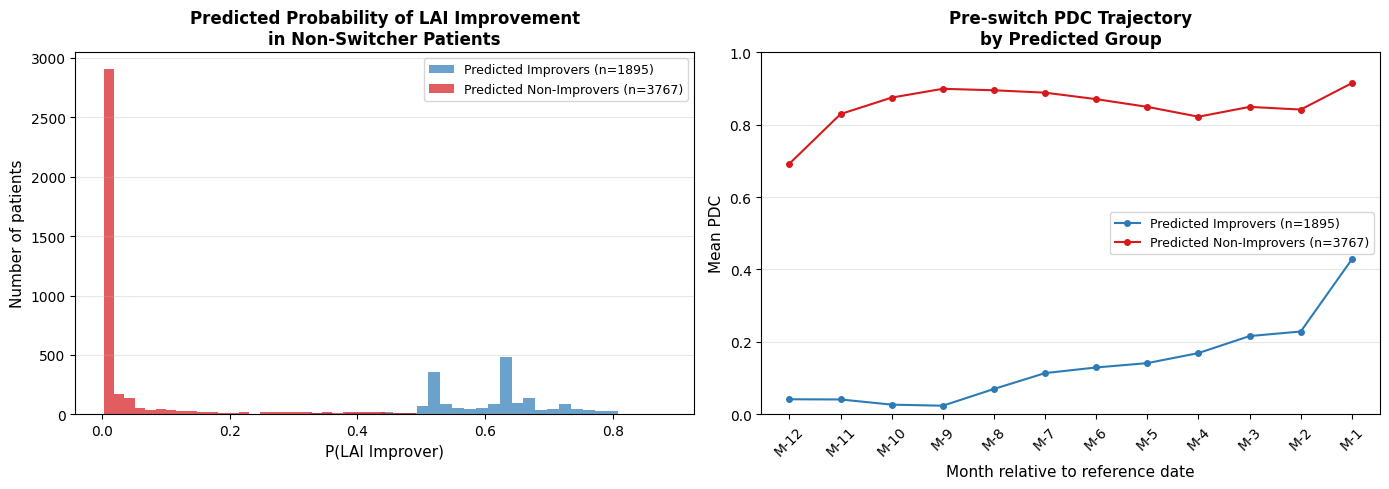

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pre_cols_ns = [f'Month_{i}' for i in range(-12, 0)]
month_labels = [f'M{i}' for i in range(-12, 0)]

# Merge predictions with PDC
plot_ns = pdc_ns.merge(results_ns[['idCas', 'predicted_improver', 'prob_LAI_improver']], 
                        on='idCas', how='left')

# ── Left: Probability distribution ───────────────────────────────────────────
axes[0].hist(plot_ns[plot_ns['predicted_improver'] == 1]['prob_LAI_improver'],
             bins=30, alpha=0.7, color='#2c7bb6', label=f'Predicted Improvers (n={predicted_improvers.sum()})')
axes[0].hist(plot_ns[plot_ns['predicted_improver'] == 0]['prob_LAI_improver'],
             bins=30, alpha=0.7, color='#d7191c', label=f'Predicted Non-Improvers (n={(~predicted_improvers).sum()})')
axes[0].set_xlabel('P(LAI Improver)', fontsize=11)
axes[0].set_ylabel('Number of patients', fontsize=11)
axes[0].set_title('Predicted Probability of LAI Improvement\nin Non-Switcher Patients', 
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ── Right: Mean PDC trajectory ────────────────────────────────────────────────
improvers    = plot_ns[plot_ns['predicted_improver'] == 1]
non_improvers = plot_ns[plot_ns['predicted_improver'] == 0]

axes[1].plot(month_labels, improvers[pre_cols_ns].mean().values,
             marker='o', markersize=4, color='#2c7bb6',
             label=f'Predicted Improvers (n={len(improvers)})')
axes[1].plot(month_labels, non_improvers[pre_cols_ns].mean().values,
             marker='o', markersize=4, color='#d7191c',
             label=f'Predicted Non-Improvers (n={len(non_improvers)})')

axes[1].set_title('Pre-switch PDC Trajectory\nby Predicted Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month relative to reference date', fontsize=11)
axes[1].set_ylabel('Mean PDC', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nonswitcher_predictions_plot.png', dpi=150, bbox_inches='tight')
plt.show()

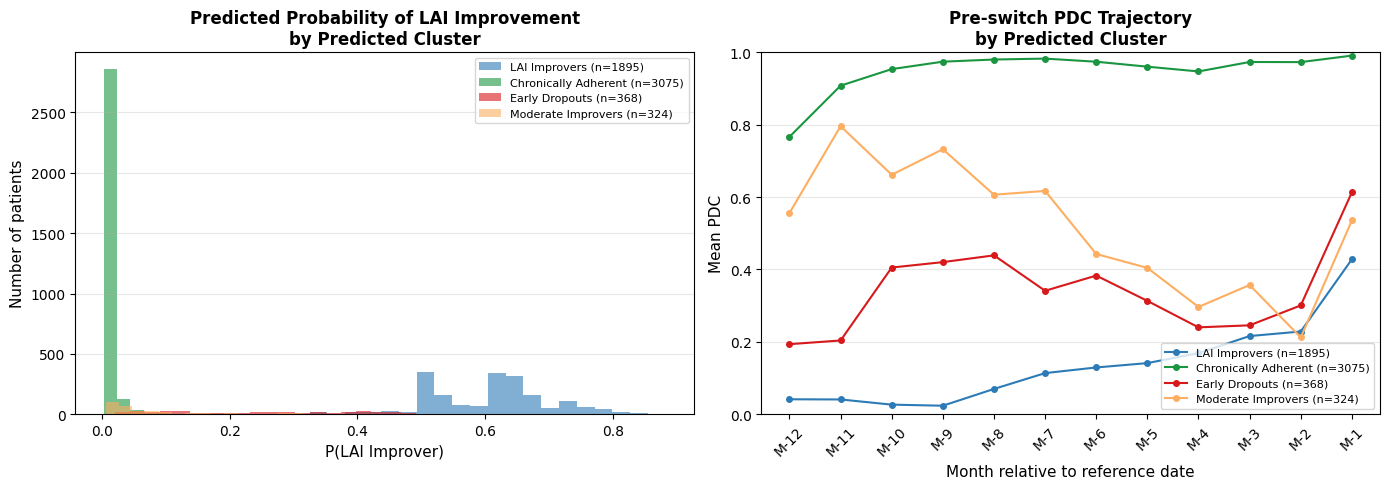

predicted_cluster
0    1895
1    3075
2     368
3     324
Name: count, dtype: int64


In [169]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_names_short = {
    0: 'LAI Improvers',
    1: 'Chronically Adherent',
    2: 'Early Dropouts',
    3: 'Moderate Improvers'
}
colors_clusters = {0: '#2c7bb6', 1: '#1a9641', 2: '#d7191c', 3: '#fdae61'}

# Merge predicted cluster into pdc_ns
plot_ns = pdc_ns.merge(results_ns[['idCas', 'predicted_cluster', 'prob_LAI_improver']],
                        on='idCas', how='left')

# ── Left: Probability distribution by predicted cluster ───────────────────────
for cluster_id, name in cluster_names_short.items():
    subset = plot_ns[plot_ns['predicted_cluster'] == cluster_id]
    axes[0].hist(subset['prob_LAI_improver'], bins=20, alpha=0.6,
                 color=colors_clusters[cluster_id], label=f'{name} (n={len(subset)})')

axes[0].set_xlabel('P(LAI Improver)', fontsize=11)
axes[0].set_ylabel('Number of patients', fontsize=11)
axes[0].set_title('Predicted Probability of LAI Improvement\nby Predicted Cluster', 
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# ── Right: Mean PDC trajectory by predicted cluster ───────────────────────────
for cluster_id, name in cluster_names_short.items():
    subset = plot_ns[plot_ns['predicted_cluster'] == cluster_id]
    if len(subset) == 0:
        continue
    mean_traj = subset[pre_cols_ns].mean()
    axes[1].plot(month_labels, mean_traj.values, marker='o', markersize=4,
                 color=colors_clusters[cluster_id],
                 label=f'{name} (n={len(subset)})')

axes[1].set_title('Pre-switch PDC Trajectory\nby Predicted Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month relative to reference date', fontsize=11)
axes[1].set_ylabel('Mean PDC', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nonswitcher_predictions_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print(plot_ns['predicted_cluster'].value_counts().sort_index())